In [152]:
from pm4py.objects.bpmn.obj import BPMN
from pm4py.objects.log.obj import EventLog
from pm4py.objects.ocel.obj import OCEL
from pm4py.objects.petri_net.obj import PetriNet, Marking
from pm4py.objects.process_tree.obj import ProcessTree
from pm4py.objects.log.importer.xes import importer as xes_importer
import pandas as pd
from IPython.display import Image
import pm4py

In [153]:
log: pd.DataFrame = pm4py.read_xes("data/raw/BPI_Challenge_2012.xes.gz")
outcome = pd.read_parquet("data/interim/outcome.parquet")["outcome"]

parsing log, completed traces ::   0%|          | 0/13087 [00:00<?, ?it/s]

In [154]:
log.head(10)

,org:resource,lifecycle:transition,concept:name,time:timestamp,case:REG_DATE,case:concept:name,case:AMOUNT_REQ
0,112,COMPLETE,A_SUBMITTED,2011-10-01 00:38:44.546000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
1,112,COMPLETE,A_PARTLYSUBMITTED,2011-10-01 00:38:44.880000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
2,112,COMPLETE,A_PREACCEPTED,2011-10-01 00:39:37.906000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
3,112,SCHEDULE,W_Completeren aanvraag,2011-10-01 00:39:38.875000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
4,NaN,START,W_Completeren aanvraag,2011-10-01 11:36:46.437000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
5,10862,COMPLETE,A_ACCEPTED,2011-10-01 11:42:43.308000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
6,10862,COMPLETE,O_SELECTED,2011-10-01 11:45:09.243000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
7,10862,COMPLETE,A_FINALIZED,2011-10-01 11:45:09.243000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
8,10862,COMPLETE,O_CREATED,2011-10-01 11:45:11.197000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
9,10862,COMPLETE,O_SENT,2011-10-01 11:45:11.380000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000


In [155]:
help(pm4py.get_variants)

Help on function get_variants in module pm4py.stats:

get_variants(log: Union[pm4py.objects.log.obj.EventLog, pandas.core.frame.DataFrame], activity_key: str = 'concept:name', timestamp_key: str = 'time:timestamp', case_id_key: str = 'case:concept:name', max_repetitions: int = 9223372036854775807) -> Union[Dict[Tuple[str], List[pm4py.objects.log.obj.Trace]], Dict[Tuple[str], int]]
    Retrieves the variants from the log.
    
    :param log: Event log (EventLog or pandas DataFrame).
    :param activity_key: Attribute to be used for the activity.
    :param timestamp_key: Attribute to be used for the timestamp.
    :param case_id_key: Attribute to be used as the case identifier.
    :param max_repetitions: Maximum number of consecutive repetitions for an activity.
                             Reduces variants by limiting consecutive activity repetitions.
    :return: A dictionary mapping activity tuples to their counts or lists of traces.
    
    .. code-block:: python3
    
        im

In [156]:
variants = pm4py.get_variants(log, activity_key="concept:name", case_id_key="case:concept:name", timestamp_key="time:timestamp")
# distinct num of variants
len(variants)

4366

In [157]:
# checking the most frequent sequences 
s = sorted(variants.items(), key=lambda kv: kv[1], reverse=True)

In [158]:
for v, n in s[:10]:
    print(f"{n:>5}  {len(v):>3}  {' -> '.join(v)}")

 3429    3  A_SUBMITTED -> A_PARTLYSUBMITTED -> A_DECLINED
 1872    6  A_SUBMITTED -> A_PARTLYSUBMITTED -> W_Afhandelen leads -> W_Afhandelen leads -> A_DECLINED -> W_Afhandelen leads
  271    8  A_SUBMITTED -> A_PARTLYSUBMITTED -> W_Afhandelen leads -> W_Afhandelen leads -> W_Afhandelen leads -> W_Afhandelen leads -> A_DECLINED -> W_Afhandelen leads
  209   10  A_SUBMITTED -> A_PARTLYSUBMITTED -> W_Afhandelen leads -> W_Afhandelen leads -> A_PREACCEPTED -> W_Completeren aanvraag -> W_Afhandelen leads -> W_Completeren aanvraag -> A_DECLINED -> W_Completeren aanvraag
  160    7  A_SUBMITTED -> A_PARTLYSUBMITTED -> A_PREACCEPTED -> W_Completeren aanvraag -> W_Completeren aanvraag -> A_DECLINED -> W_Completeren aanvraag
  134    7  A_SUBMITTED -> A_PARTLYSUBMITTED -> A_PREACCEPTED -> W_Completeren aanvraag -> W_Completeren aanvraag -> A_CANCELLED -> W_Completeren aanvraag
  126   12  A_SUBMITTED -> A_PARTLYSUBMITTED -> W_Afhandelen leads -> W_Afhandelen leads -> A_PREACCEPTED -> W_Complet

In [159]:
# most frequent sequences (top 3): 
# A_SUBMITTED -> A_PARTLYSUBMITTED -> A_DECLINED (3429)
# A_SUBMITTED -> A_PARTLYSUBMITTED -> W_Afhandelen leads -> W_Afhandelen leads -> A_DECLINED -> W_Afhandelen leads (1872)
# A_SUBMITTED -> A_PARTLYSUBMITTED -> W_Afhandelen leads -> W_Afhandelen leads -> W_Afhandelen leads ->
# W_Afhandelen leads -> A_DECLINED -> W_Afhandelen leads (271)

In [233]:
help(pm4py.discover_petri_net_inductive)

Help on function discover_petri_net_inductive in module pm4py.discovery:

discover_petri_net_inductive(log: Union[pm4py.objects.log.obj.EventLog, pandas.core.frame.DataFrame, pm4py.objects.dfg.obj.DirectlyFollowsGraph], multi_processing: bool = False, noise_threshold: float = 0.0, activity_key: str = 'concept:name', timestamp_key: str = 'time:timestamp', case_id_key: str = 'case:concept:name', disable_fallthroughs: bool = False) -> Tuple[pm4py.objects.petri_net.obj.PetriNet, pm4py.objects.petri_net.obj.Marking, pm4py.objects.petri_net.obj.Marking]
    Discovers a Petri net using the Inductive Miner algorithm.
    
    The Inductive Miner detects a 'cut' in the log (e.g., sequential, parallel, concurrent, loop) and recursively applies the algorithm to sublogs until a base case is found.
    Inductive miner models typically use hidden transitions for skipping or looping portions of the model, and each visible transition has a unique label.
    
    :param log: Event log, Pandas DataFrame

In [225]:
log_a = log[log["concept:name"].str.startswith("A_")]

In [234]:
# displaying a petri net but only for logs of states of the application
net, im, fm = pm4py.discover_petri_net_inductive(
    log_a, 
    activity_key="concept:name", 
    case_id_key="case:concept:name", 
    timestamp_key="time:timestamp")

In [235]:
pm4py.save_vis_petri_net(net, im, fm, "petri_net_log_a.png")

''

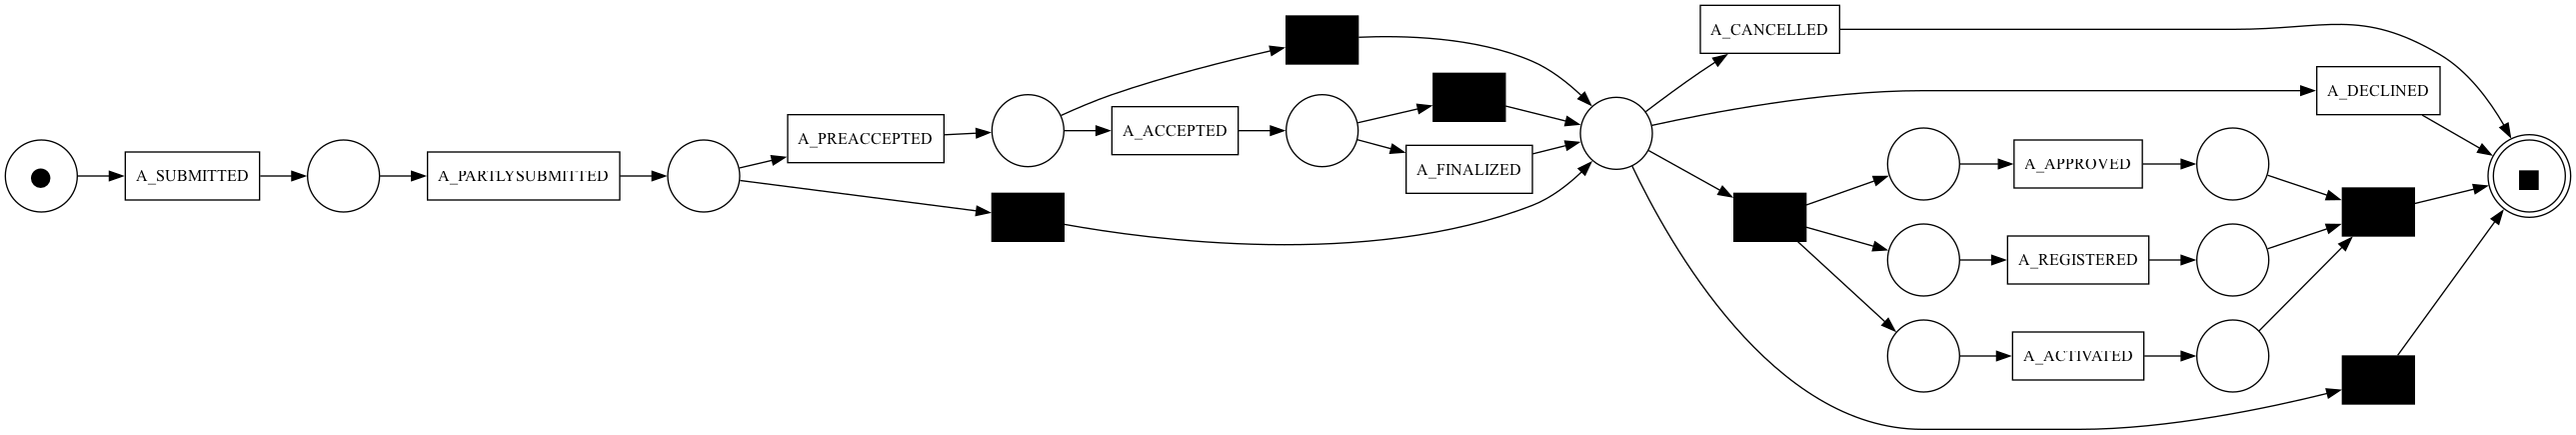

In [236]:
Image("petri_net_log_a.png")

In [237]:
# box with a label -> activity from the logs
# circles are states 
# black boxes are silent transitions (label is None)

In [230]:
log_a_o = log[log["concept:name"].str.startswith(("A_", "O_"))]

In [238]:
# petri net but only for logs that start with A_ and O_ (states of the application & states of the offer belonging to the application)
net, im, fm = pm4py.discover_petri_net_inductive(
    log_a_o, 
    activity_key="concept:name", 
    case_id_key="case:concept:name", 
    timestamp_key="time:timestamp")
pm4py.save_vis_petri_net(net, im, fm, "petri_net_log_a_o.png")

''

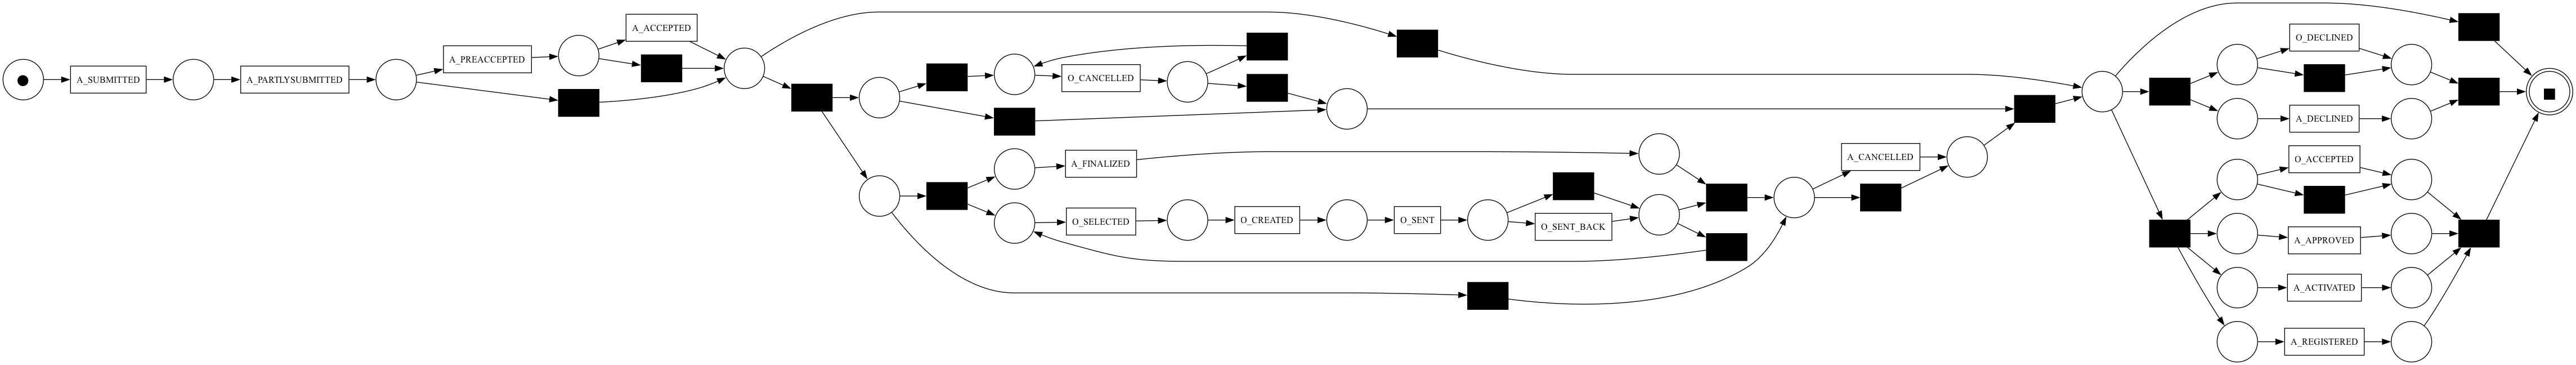

In [239]:
Image("petri_net_log_a_o.png")

In [240]:
o_dec = log.loc[log["concept:name"] == "O_DECLINED", "case:concept:name"].unique()
outcome[outcome.index.isin(o_dec)].value_counts()

outcome
A_DECLINED    802
Name: count, dtype: int64

In [241]:
# this confirms that every O_Declined (an offer decline by the bank) ends with a A_Declined (a decline by the application)
# so we have only one offer per application and not more

In [242]:
# full petri net 
net, im, fm = pm4py.discover_petri_net_inductive(
    log, 
    activity_key="concept:name", 
    case_id_key="case:concept:name", 
    timestamp_key="time:timestamp")
pm4py.save_vis_petri_net(net, im, fm, "petri_net_log.png")

''

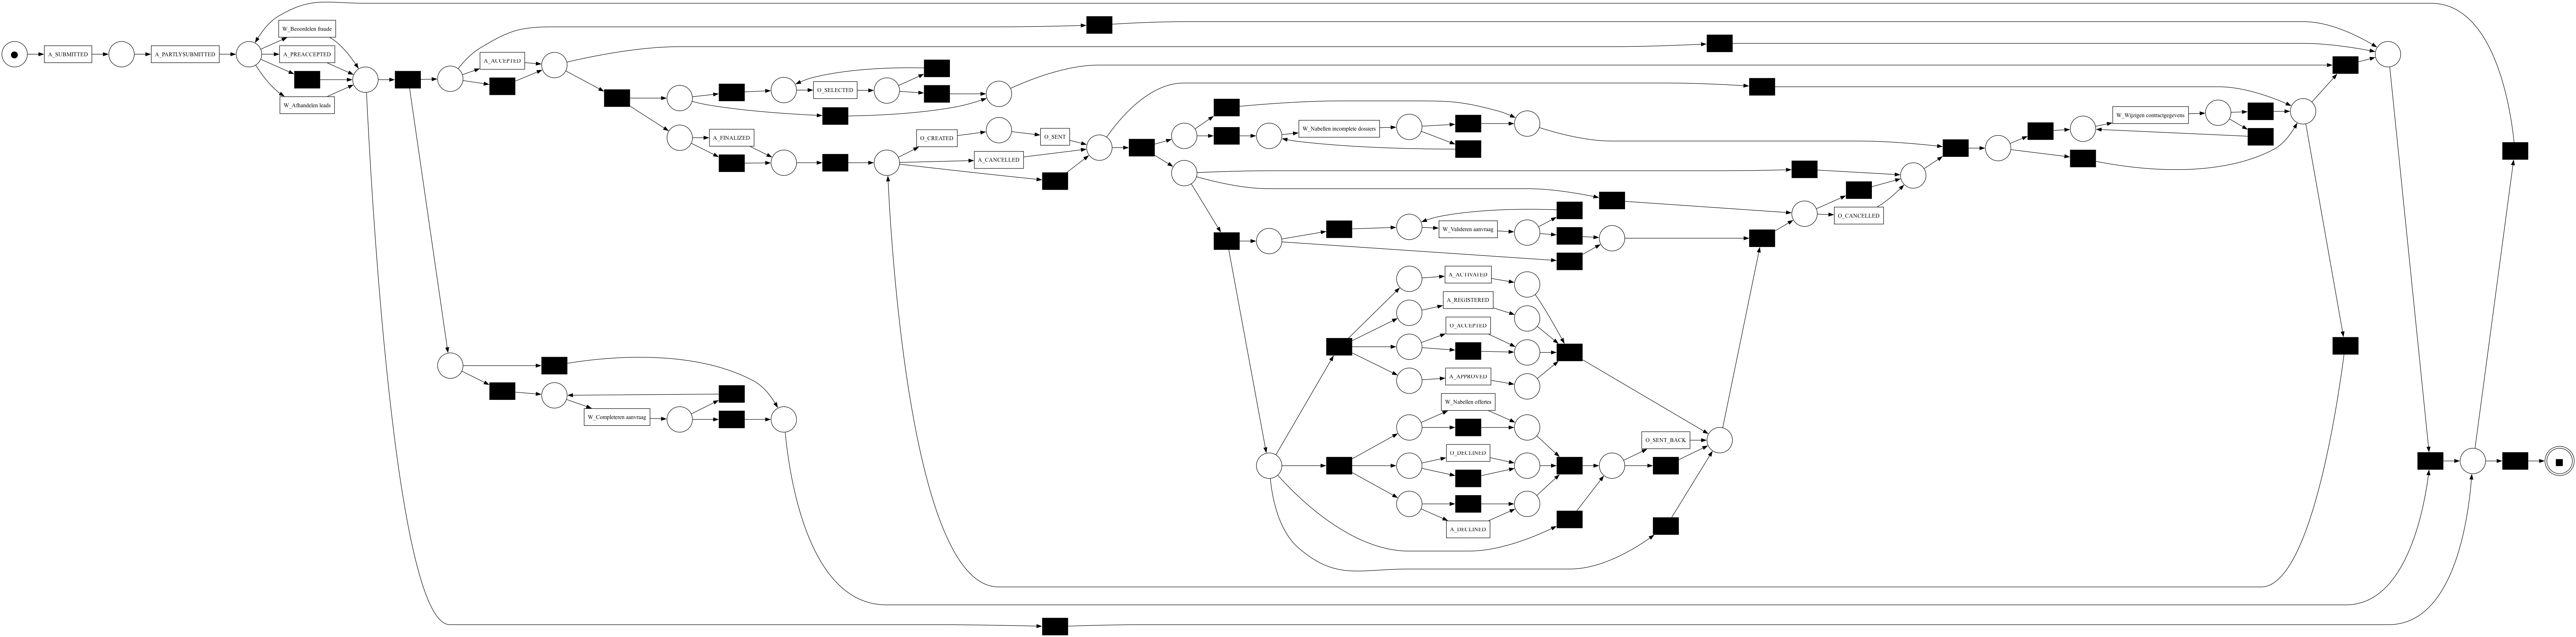

In [243]:
Image("petri_net_log.png")

/Users/mudarshullar/miniconda3/lib/python3.10/site-packages/pm4py/algo/discovery/dfg/adapters/pandas/df_statistics.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[start_timestamp_key] = df[timestamp_key]


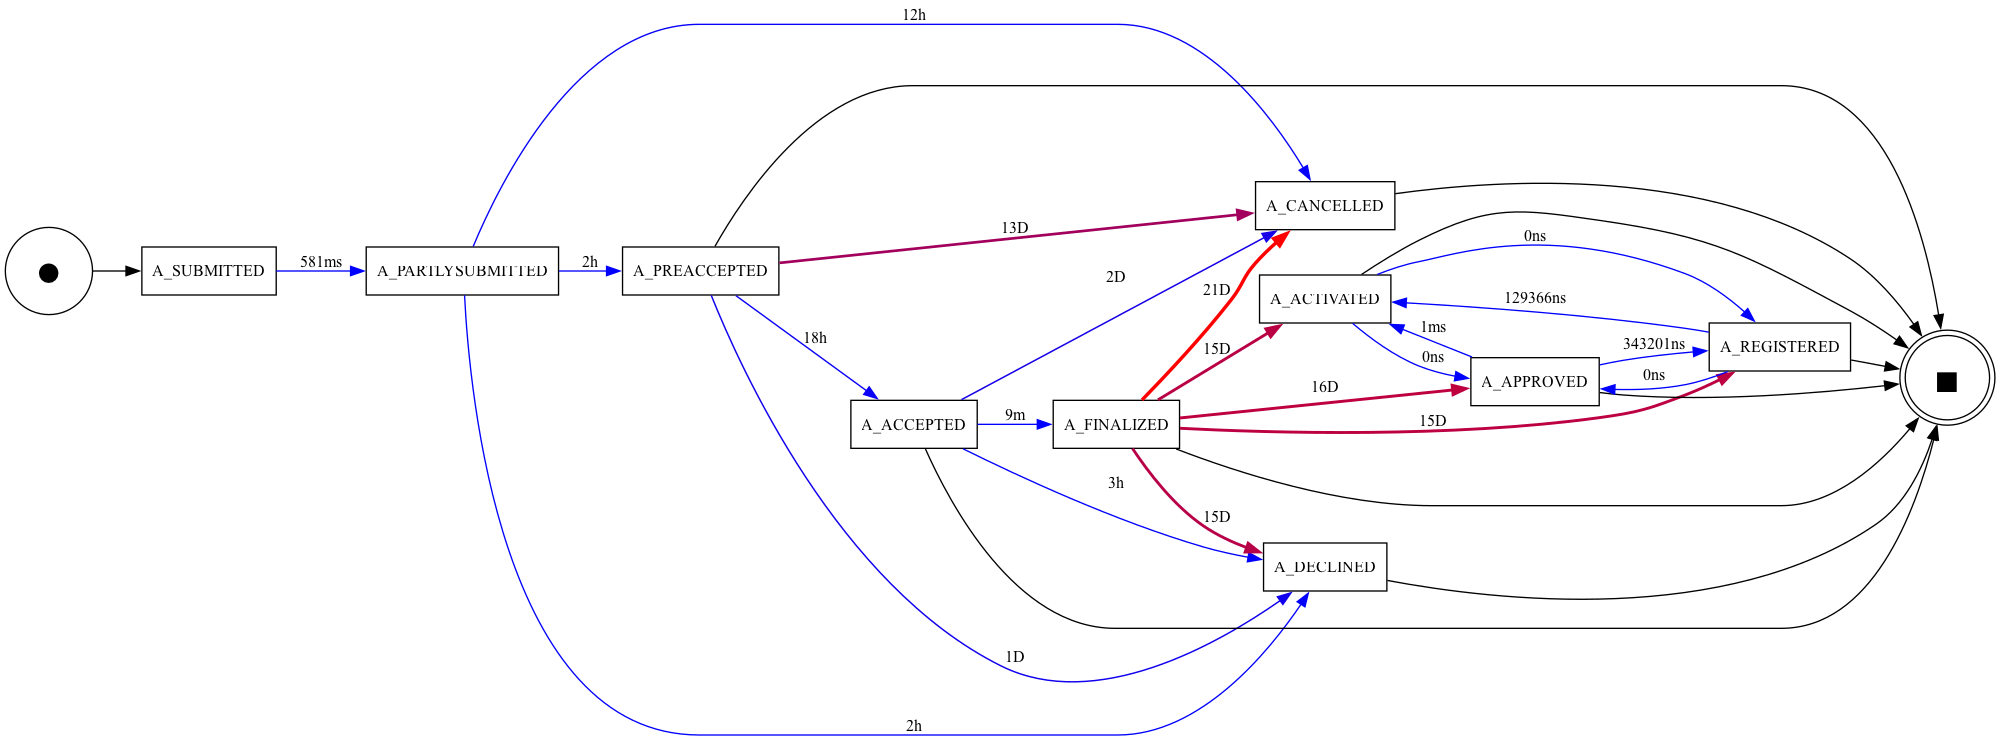

In [244]:
# dfg net for logs related to the states of the application with durations
dfg, sa, ea = pm4py.discover_performance_dfg(
    log_a,
    activity_key="concept:name",
    case_id_key="case:concept:name",
    timestamp_key="time:timestamp"
)

pm4py.save_vis_performance_dfg(dfg, sa, ea, "perf_dfg_log_a.png")
Image("perf_dfg_log_a.png")

/Users/mudarshullar/miniconda3/lib/python3.10/site-packages/pm4py/algo/discovery/dfg/adapters/pandas/df_statistics.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[start_timestamp_key] = df[timestamp_key]


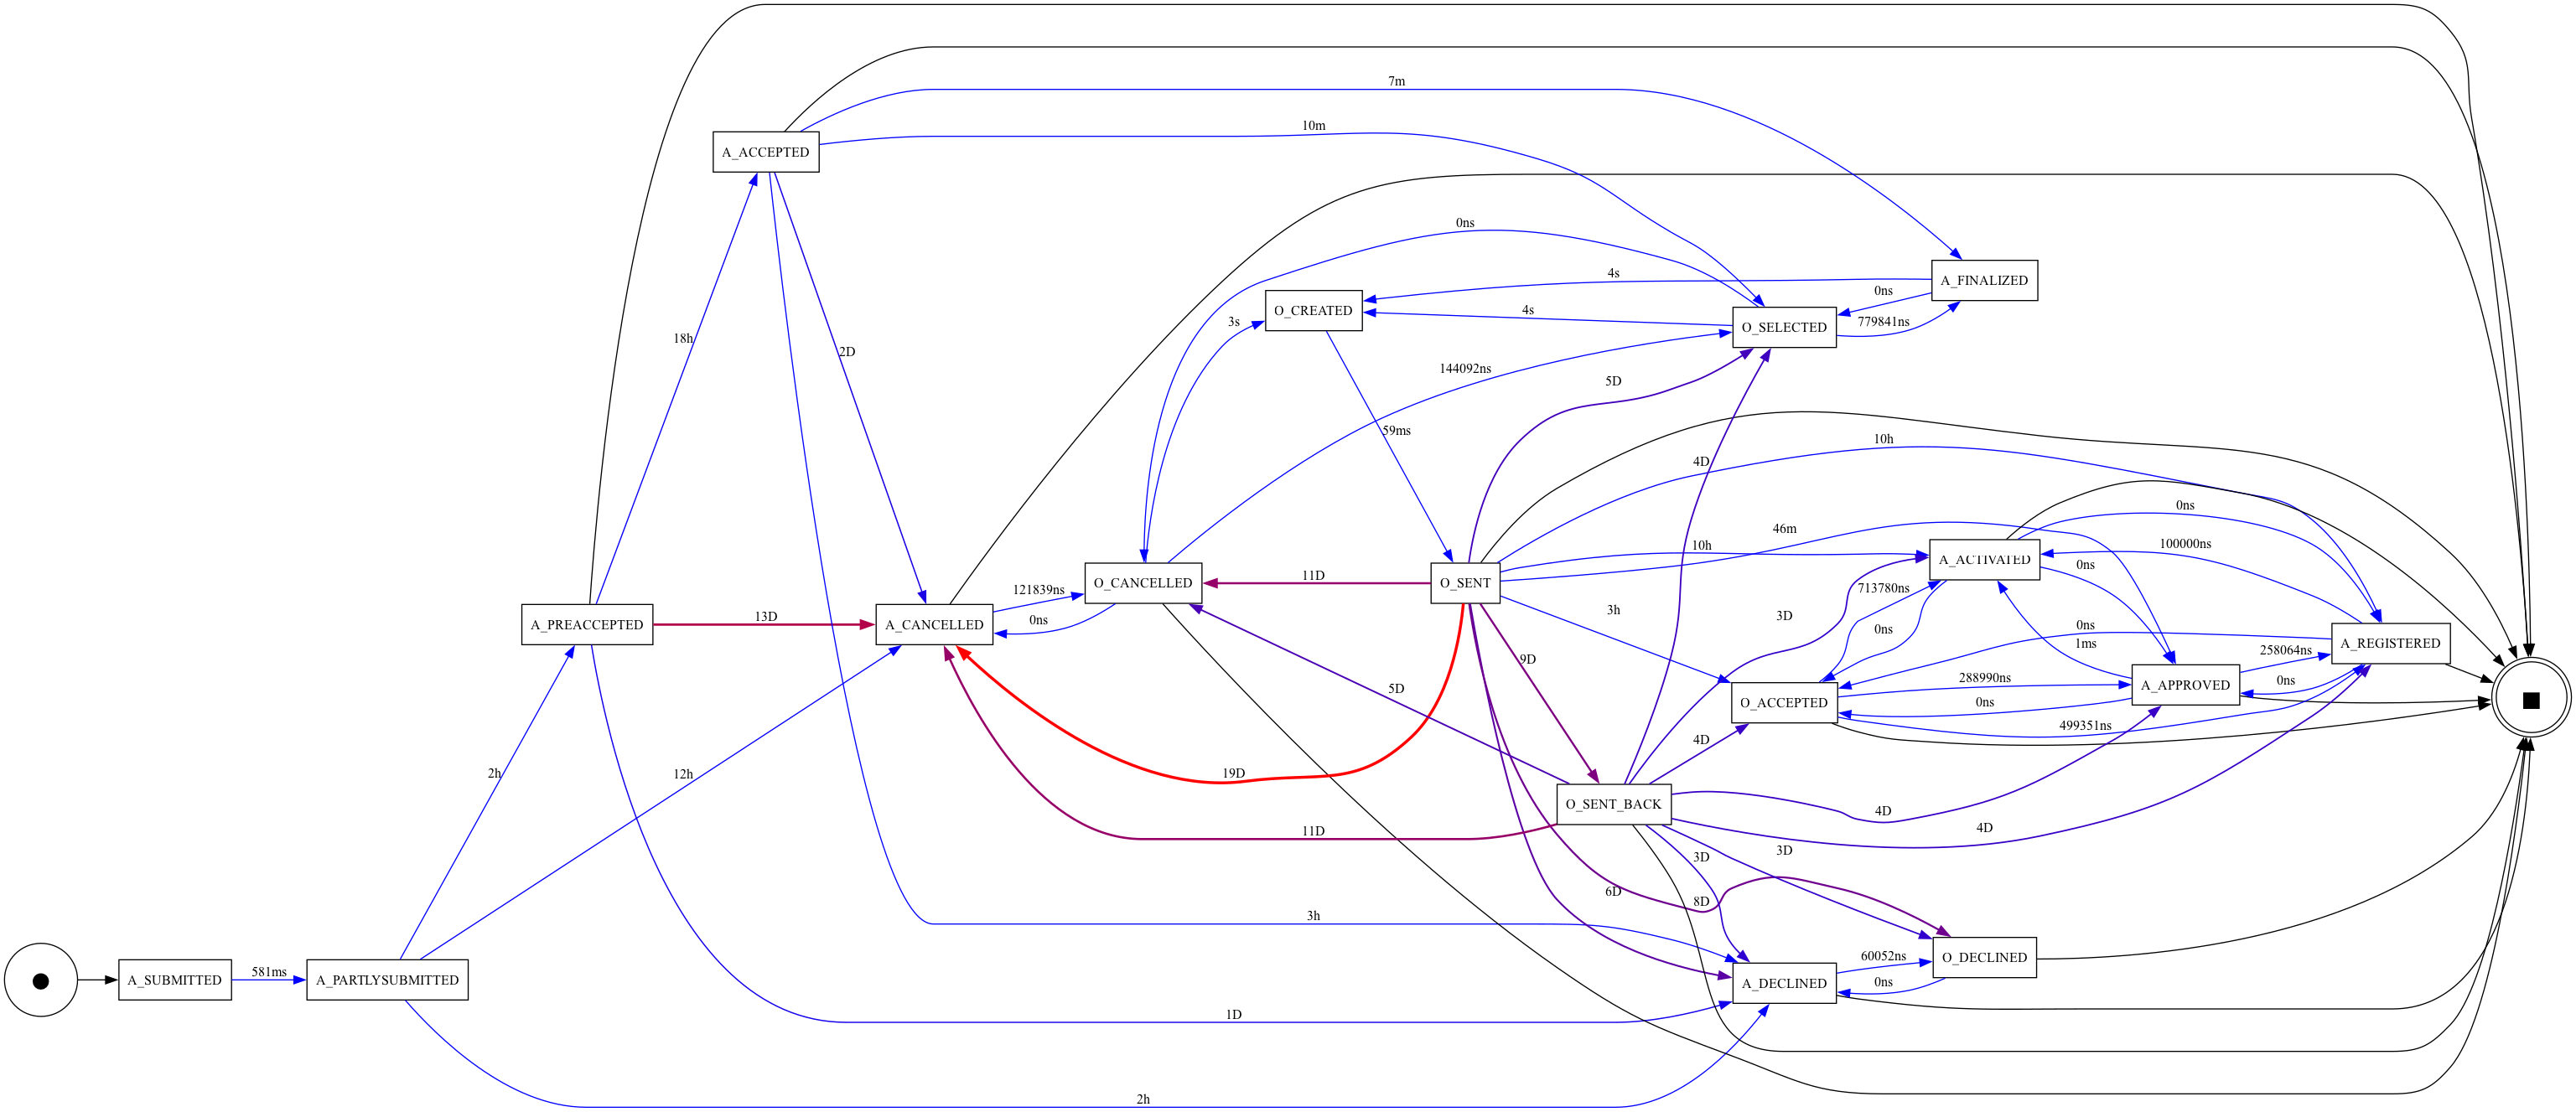

In [245]:
# dfg net for logs related to the states of the application and offer with durations
dfg, sa, ea = pm4py.discover_performance_dfg(
    log_a_o,
    activity_key="concept:name",
    case_id_key="case:concept:name",
    timestamp_key="time:timestamp"
)

pm4py.save_vis_performance_dfg(dfg, sa, ea, "perf_dfg_log_a_o.png")
Image("perf_dfg_log_a_o.png")

In [175]:
# ping-pong: cases where an activity recurs two steps later with another in between
a = log.groupby("case:concept:name")["concept:name"].agg(list)

def pingpong(seq):
    return sum(1 for i in range(len(seq)-2)
               if seq[i] == seq[i+2] and seq[i] != seq[i+1])

pp = a.apply(pingpong)
(pp > 0).sum()

np.int64(9318)

In [176]:
# straight-through: cases with no back-and-forth
(pp == 0).sum()

np.int64(3769)

In [201]:
# work time vs queue time per work item activity, in minutes (median)
w = log[log["concept:name"].str.startswith("W_")]

w["next_ts"]  = w.groupby("case:concept:name")["time:timestamp"].shift(-1)
w["next_lc"]  = w.groupby("case:concept:name")["lifecycle:transition"].shift(-1)
w["next_act"] = w.groupby("case:concept:name")["concept:name"].shift(-1)
w["minutes"]  = (w["next_ts"] - w["time:timestamp"]).dt.total_seconds() / 60

same = w["next_act"] == w["concept:name"]

work  = w[(w["lifecycle:transition"] == "START")    & (w["next_lc"] == "COMPLETE") & same]
queue = w[(w["lifecycle:transition"] == "SCHEDULE") & (w["next_lc"] == "START")    & same]

pd.DataFrame({
    "work_min":  work.groupby("concept:name")["minutes"].median(),
    "queue_min": queue.groupby("concept:name")["minutes"].median(),
}).round(1)

/var/folders/br/2_wcc4013sjd9m6nf62t0zf80000gn/T/ipykernel_59584/2565795453.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  w["next_ts"]  = w.groupby("case:concept:name")["time:timestamp"].shift(-1)
/var/folders/br/2_wcc4013sjd9m6nf62t0zf80000gn/T/ipykernel_59584/2565795453.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  w["next_lc"]  = w.groupby("case:concept:name")["lifecycle:transition"].shift(-1)
/var/folders/br/2_wcc4013sjd9m6nf62t0zf80000gn/T/ipykernel_59584/2565795453.py:5: SettingWithCopyWar

,work_min,queue_min
concept:name,,
W_Afhandelen leads,2.0,42.4
W_Beoordelen fraude,0.1,1129.0
W_Completeren aanvraag,1.9,109.8
W_Nabellen incomplete dossiers,2.4,NaN
W_Nabellen offertes,2.0,NaN
W_Valideren aanvraag,9.5,0.3


In [193]:
# total queue time vs total work time across the whole log
print(f"work:  {work['minutes'].sum()/1440:,.0f} days")
print(f"queue: {queue['minutes'].sum()/1440:,.0f} days")
print(f"ratio: {queue['minutes'].sum()/work['minutes'].sum():.1f}x")

work:  512 days
queue: 2,503 days
ratio: 4.9x


Text(0.5, 0, 'hour scheduled')

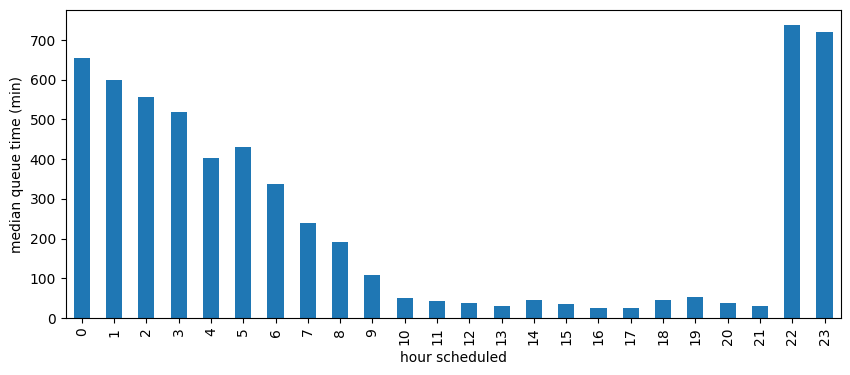

In [195]:
# is the queue just overnight?
q = queue.copy()
q["hour"] = q["time:timestamp"].dt.tz_convert("Europe/Amsterdam").dt.hour

ax = q.groupby("hour")["minutes"].median().plot.bar(figsize=(10,4))
ax.set_ylabel("median queue time (min)")
ax.set_xlabel("hour scheduled")

Text(0.5, 0, 'day scheduled')

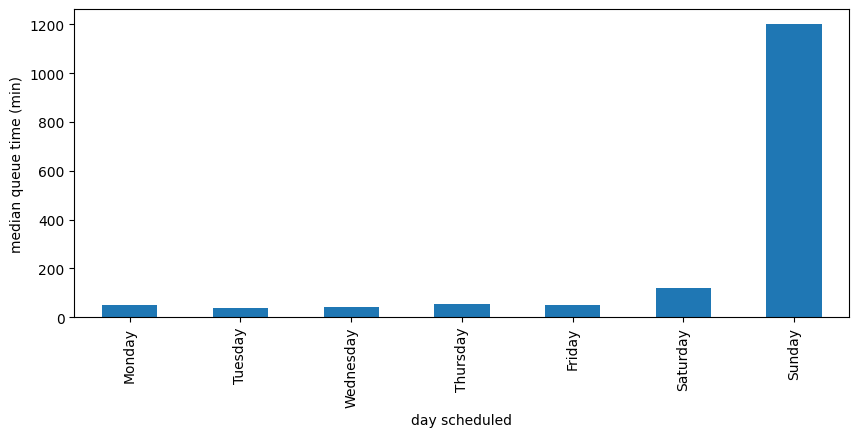

In [199]:
# median queue time by weekday (local time)
q = queue.copy()
q["dow"] = q["time:timestamp"].dt.tz_convert("Europe/Amsterdam").dt.day_name()

order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
by_dow = q.groupby("dow")["minutes"].median().reindex(order)

ax = by_dow.plot.bar(figsize=(10,4))
ax.set_ylabel("median queue time (min)")
ax.set_xlabel("day scheduled")

In [247]:
# number of queue events per hour of day (unfiltered — no timezone conversion)
queue.groupby("hour").size()

hour
0     172
1      71
2      37
3      23
4      18
5       5
6      30
7      82
8     143
9     438
10    606
11    735
12    659
13    693
14    782
15    669
16    707
17    534
18    571
19    649
20    698
21    580
22    464
23    299
dtype: int64

In [204]:
# how much delay each activity contributes?
q = queue.groupby("concept:name")["minutes"]

impact = pd.DataFrame({
    "median_min": q.median(),
    "n": q.size(),
    "total_days": q.sum() / 1440,
}).sort_values("total_days", ascending=False).round(1)

impact

,median_min,n,total_days
concept:name,,,
W_Completeren aanvraag,109.8,4852,1393.5
W_Afhandelen leads,42.4,4740,1016.0
W_Beoordelen fraude,1129.0,69,93.6
W_Valideren aanvraag,0.3,4,0.0


In [209]:
outcomes = ["A_APPROVED", "A_DECLINED", "A_CANCELLED"]

labels = (
    log[log["concept:name"].isin(outcomes)]
    .groupby("case:concept:name")["concept:name"]
    .agg(list)
)

labels.apply(len).value_counts()
log_complete = log[log["case:concept:name"].isin(labels.index)]
duration = log_complete.groupby("case:concept:name")["time:timestamp"].agg(["min", "max"])
duration["days"] = (duration["max"] - duration["min"]).dt.total_seconds() / 86400

In [212]:
# does ping pong cost time?
d = pd.DataFrame({
    "days": duration["days"],
    "outcome": outcome,
    "pingpong": pp.gt(0),
})

d.groupby(["outcome", "pingpong"])["days"].agg(
    median_days="median",
    cases="size"
)

median_days  cases
outcome     pingpong                    
A_APPROVED  True        14.485519   2246
A_CANCELLED False       30.624107    283
            True        13.978930   2524
A_DECLINED  False        0.000438   3440
            True         0.401015   4195